In [8]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score


import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
heights = [None] * 4  # Participant demographics removed for confidentiality
weights = [None] * 4
ages = [None] * 4
genders = [None] * 4

person1_df = [night1, night2, night3, night4, night5, night6, night7, night8, night9, night10, night11, night12, night13, night14]
person2_df=[night15, night16, night17, night18, night19, night20, night21, night22, night23]
person3_df=[night24, night25, night26,night27,night28,night29,night30,night31,night32, night33,night34,night35,night36,night37]
person4_df=[night38,night39,night40,night41,night42,night43,night44,night45]

for df in person1_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[0]
        df.at[i, 'Weight'] = weights[0]
        df.at[i, 'Age'] = ages[0]
        df.at[i, 'Gender'] = genders[0]

for df in person2_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[1]
        df.at[i, 'Weight'] = weights[1]
        df.at[i, 'Age'] = ages[1]
        df.at[i, 'Gender'] = genders[1]

for df in person3_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[2]
        df.at[i, 'Weight'] = weights[2]
        df.at[i, 'Age'] = ages[2]
        df.at[i, 'Gender'] = genders[2]

for df in person4_df:
    for i in range(len(df)):
        df.at[i, 'Height'] = heights[3]
        df.at[i, 'Weight'] = weights[3]
        df.at[i, 'Age'] = ages[3]
        df.at[i, 'Gender'] = genders[3]


In [11]:
# List of DataFrames
night_dfs = [night1, night2, night3, night4, night5, night6, night7, night8, night9, night10, night11, night12, night13, night14, night15, night16, night17, night18, night19, night20, night21, night22, night23, night24, night25, night26,night27,night28,night29,night30,night31,night32, night33,night34,night35,night36,night37,night38,night39,night40,night41,night42,night43,night44,night45]

# Assign unique night IDs to each DataFrame
for i, df in enumerate(night_dfs):
    df['night_id'] = i  # Assigning a unique ID for each night

# Combine all DataFrames into a single DataFrame
combined_data = pd.concat(night_dfs, ignore_index=True)

In [ ]:
features = ['rmssd', 'hf', 'lf', 'Infrared to Red Signal Ratio', 'Age', 'Gender', 'Height', 'Weight', 'glucose']

# Assuming 'your_dataframe' contains all the necessary features
table_df = combined_data[features]

table_df.describe()

In [13]:
for lag in range(1, 18):  
    #combined_data[f'glucose_lag_{lag}'] = combined_data.groupby('night_id')['glucose'].shift(lag)
    combined_data[f'rmssd_lag_{lag}'] = combined_data.groupby('night_id')['rmssd'].shift(lag)
    combined_data[f'lf_lag_{lag}'] = combined_data.groupby('night_id')['lf'].shift(lag)
    combined_data[f'hf_lag_{lag}'] = combined_data.groupby('night_id')['hf'].shift(lag)
    combined_data[f'oxygen_lag_{lag}'] = combined_data.groupby('night_id')['Infrared to Red Signal Ratio'].shift(lag)

# Drop NaN values created by shifting
combined_data.dropna(inplace=True)

# Check if any NaNs remain
print(combined_data.isna().sum())


timestamp        0
rmssd            0
lf               0
hf               0
glucose          0
                ..
oxygen_lag_16    0
rmssd_lag_17     0
lf_lag_17        0
hf_lag_17        0
oxygen_lag_17    0
Length: 79, dtype: int64


In [14]:
# One-hot encode categorical variables
combined_data = pd.get_dummies(combined_data, columns=['Gender'], drop_first=True)

# Scale numerical features
scaler = StandardScaler()
numerical_cols = ['Height', 'Age', 'Weight']
combined_data[numerical_cols] = scaler.fit_transform(combined_data[numerical_cols])

# Prepare features and target variable
X = combined_data.drop(columns=['timestamp', 'glucose', 'night_id'])  # Drop the target variable and time column
y = combined_data['glucose']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [17]:
print(X_train.shape)

(2536, 76)


In [ ]:
# Number of features (4 features × 18 lag values)
num_features = 76  # = 72

batch_size = 8

sample_input = np.random.rand(batch_size, num_features)  # Shape: (8, 72)
print(sample_input.shape)  

rf_predictions = model.predict(sample_input)
print(f"Random Forest Predictions Shape: {rf_predictions.shape}")  # (8,)

(8, 76)
Random Forest Predictions Shape: (8,)


/Users/tomliu/Library/Python/3.11/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [29]:
import time
start_time = time.time()
rf_predictions = model.predict(sample_input)
rf_time = (time.time() - start_time)/(sample_input.shape[0]) * 1000 
print(f"Random Forest Inference Time: {rf_time:.6f} ms")

/Users/tomliu/Library/Python/3.11/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


Random Forest Inference Time: 42.277634 ms


In [22]:
predictions = model.predict(X_test)


In [24]:
import joblib
import os
joblib.dump(model, "random_forest_model.pkl")

# Get model size in MB
model_size_mb = os.path.getsize("random_forest_model.pkl") / (1024 ** 2)
print(f"Random Forest Model Size: {model_size_mb:.3f} MB")

Random Forest Model Size: 31.985 MB


In [ ]:
predictions = model.predict(X_test)

# Calculate evaluation metrics
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print(f"Mean Squared Error: {mse}")
print(f"Root Mean Square Error: {rmse}")
print(f"R² Score: {r2}")

importances = model.feature_importances_
feature_names = X_train.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

# Aggregate lag importance into base variables
aggregated_importance = {}

for index, row in feature_importance_df.iterrows():
    feature = row['Feature']
    importance = row['Importance']
    
    # Extract base feature name (remove _lag_X)
    base_feature = feature.split('_lag')[0] if '_lag' in feature else feature
    
    if base_feature in aggregated_importance:
        aggregated_importance[base_feature] += importance
    else:
        aggregated_importance[base_feature] = importance

# Convert aggregated importance to DataFrame
aggregated_importance_df = pd.DataFrame(list(aggregated_importance.items()), columns=['Feature', 'Total Importance'])

# Sort and display
print(aggregated_importance_df.sort_values(by='Total Importance', ascending=False))


Mean Squared Error: 0.38379651971608836
Root Mean Square Error: 0.6195131311893949
R² Score: 0.22051844934979425
                        Feature  Total Importance
0                         rmssd          0.275529
1                            lf          0.228504
7                        oxygen          0.191500
2                            hf          0.165840
4                        Height          0.068561
6                           Age          0.056800
3  Infrared to Red Signal Ratio          0.012920
5                        Weight          0.000199
8                   Gender_Male          0.000148


(<module 'matplotlib.pyplot' from '/Users/tomliu/Library/Python/3.11/lib/python/site-packages/matplotlib/pyplot.py'>,
 [569, 41, 0, 24, 0])

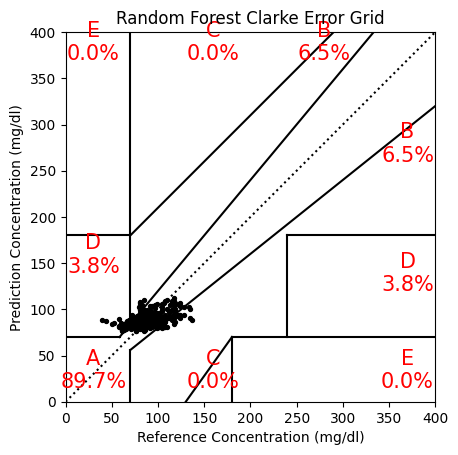

In [ ]:

def clarke_error_grid(ref_values, pred_values, title_string):
    ref_values = np.array(ref_values) * 18
    pred_values = np.array(pred_values) * 18
    total_points = len(ref_values)  # Total number of points

    # Set up plot
    plt.scatter(ref_values, pred_values, marker='o', color='black', s=8)
    plt.title(title_string + " Clarke Error Grid")
    plt.xlabel("Reference Concentration (mg/dl)")
    plt.ylabel("Prediction Concentration (mg/dl)")
    plt.xticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.yticks([0, 50, 100, 150, 200, 250, 300, 350, 400])
    plt.gca().set_facecolor('white')

    # Set axes lengths
    plt.gca().set_xlim([0, 400])
    plt.gca().set_ylim([0, 400])
    plt.gca().set_aspect((400)/(400))

    # Plot zone lines
    plt.plot([0, 400], [0, 400], ':', c='black')                      # Theoretical 45 regression line
    plt.plot([0, 175/3], [70, 70], '-', c='black')
    plt.plot([175/3, 400/1.2], [70, 400], '-', c='black')           
    plt.plot([70, 70], [84, 400],'-', c='black')
    plt.plot([0, 70], [180, 180], '-', c='black')
    plt.plot([70, 290], [180, 400], '-', c='black')
    plt.plot([70, 70], [0, 56], '-', c='black')                    
    plt.plot([70, 400], [56, 320],'-', c='black')
    plt.plot([180, 180], [0, 70], '-', c='black')
    plt.plot([180, 400], [70, 70], '-', c='black')
    plt.plot([240, 240], [70, 180],'-', c='black')
    plt.plot([240, 400], [180, 180], '-', c='black')
    plt.plot([130, 180], [0, 70], '-', c='black')

    zone = [0] * 5 
    for i in range(len(ref_values)):
        if (ref_values[i] <= 70 and pred_values[i] <= 70) or (pred_values[i] <= 1.2 * ref_values[i] and pred_values[i] >= 0.8 * ref_values[i]):
            zone[0] += 1  # Zone A

        elif (ref_values[i] >= 180 and pred_values[i] <= 70) or (ref_values[i] <= 70 and pred_values[i] >= 180):
            zone[4] += 1  # Zone E

        elif ((ref_values[i] >= 70 and ref_values[i] <= 290) and pred_values[i] >= ref_values[i] + 110) or ((ref_values[i] >= 130 and ref_values[i] <= 180) and (pred_values[i] <= (7/5) * ref_values[i] - 182)):
            zone[2] += 1  # Zone C

        elif (ref_values[i] >= 240 and (pred_values[i] >= 70 and pred_values[i] <= 180)) or (ref_values[i] <= 175/3 and pred_values[i] <= 180 and pred_values[i] >= 70) or ((ref_values[i] >= 175/3 and ref_values[i] <= 70) and pred_values[i] >= (6/5) * ref_values[i]):
            zone[3] += 1  # Zone D

        else:
            zone[1] += 1  # Zone B

    zone_percentages = [100 * (z / total_points) for z in zone]

    # Add zone labels with percentage in red
    plt.text(30, 15, f"A\n{zone_percentages[0]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 260, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(280, 370, f"B\n{zone_percentages[1]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 370, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(160, 15, f"C\n{zone_percentages[2]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 140, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 120, f"D\n{zone_percentages[3]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(30, 370, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')
    plt.text(370, 15, f"E\n{zone_percentages[4]:.1f}%", fontsize=15, color='red', ha='center')

    return plt, zone

clarke_error_grid(y_test, predictions, "Random Forest")


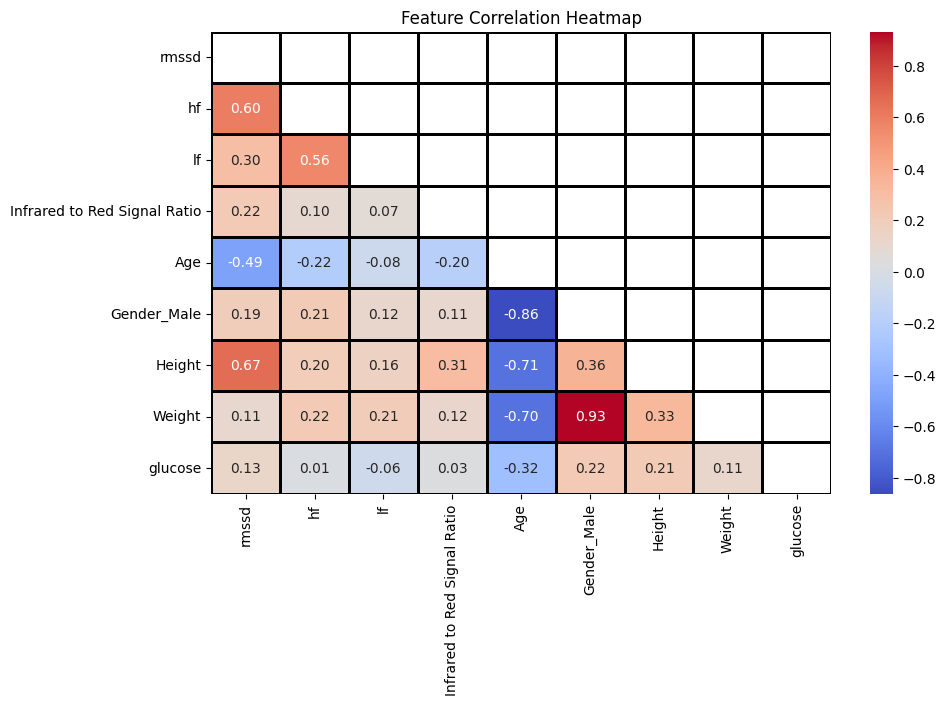

In [ ]:
features = ['rmssd', 'hf', 'lf', 'Infrared to Red Signal Ratio', 'Age', 'Gender_Male', 'Height', 'Weight', 'glucose']

heatmap_df = combined_data[features]  

corr_matrix = heatmap_df.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix, 
    mask=mask, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=1,  
    linecolor='black'
)
plt.title("Feature Correlation Heatmap")
plt.show()


In [ ]:

# Drop lag features (assuming they follow a naming pattern like "lag_")
combined_data = combined_data[[col for col in combined_data.columns if "lag" not in col]]

# Identify columns to unstandardize
columns_to_unstandardize = ["age", "weight", "height"]

# Ensure only existing columns are selected
columns_to_unstandardize = [col for col in columns_to_unstandardize if col in combined_data.columns]

# Unstandardize using inverse_transform
if columns_to_unstandardize:
    combined_data[columns_to_unstandardize] = scaler.inverse_transform(combined_data[columns_to_unstandardize])

combined_data.describe()
